In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
real_data = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/all_data_new.csv")
print(real_data.head())

            Unnamed: 0      TE0001      TE0002      TE0003      TE0004  \
0  2024-03-01 02:00:00  303.028605  303.053759  303.174631  303.203880   
1  2024-03-01 02:01:00  303.029702  303.056293  303.179008  303.204182   
2  2024-03-01 02:02:00  303.026310  303.054102  303.178160  303.197538   
3  2024-03-01 02:03:00  303.019043  303.049507  303.178479  303.203466   
4  2024-03-01 02:04:00  303.011180  303.038769  303.166208  303.197511   

       TE0005      TE0006      TE0007      TE0008      TE0009  ...    4CV4201  \
0  303.115393  302.999685  302.902130  302.974455  302.869267  ...  10.355179   
1  303.110369  302.987287  302.896517  302.972414  302.876941  ...  10.355179   
2  303.101433  302.980435  302.888268  302.961777  302.871540  ...  10.355179   
3  303.102022  302.979992  302.885417  302.955737  302.861689  ...  10.355179   
4  303.105031  302.984144  302.891010  302.961676  302.863612  ...  10.355179   

    4CV4150   4CV4400   4CV4410   4CV4415   4CV4416  4PDT4500   4FT4

In [39]:
columns = real_data.columns.tolist()
print(columns)

# Create mock dataset with same structure as real_data
# Convert the datetime column to DatetimeIndex
datetime_index = pd.to_datetime(real_data['Unnamed: 0'])
# Limit to 30 days from the start
start_time = datetime_index.iloc[0]
end_time = start_time + pd.Timedelta(days=30)
datetime_index = datetime_index[datetime_index <= end_time]

# Convert to total seconds since first timestamp for sinusoidal calculations
# Use .dt.total_seconds() since datetime_index is a Series, not DatetimeIndex
time_seconds = (datetime_index - datetime_index.iloc[0]).dt.total_seconds()

# Create a copy of real_data structure, but only for the 30-day period
# Convert 'Unnamed: 0' to datetime for proper comparison
real_data_datetime = pd.to_datetime(real_data['Unnamed: 0'])
mask = real_data_datetime <= end_time
mock_data = real_data.loc[mask].copy()

# Get TE columns (columns starting with 'TE') and sort them
te_columns = sorted([col for col in real_data.columns if col.startswith('TE')])
# Get IE_Card columns and sort them
ie_columns = sorted([col for col in real_data.columns if col.startswith('IE_Card')])

# Parameters for the model
R = 100.0    # Assumed resistance (Ohm) - same for all cards
channels_per_card = 24  # 24 channels per IE_Card

# Define real resistance (R_R) for each IE_Card
# IE_Card04 has R_R = 25, others have slightly different values around 100
R_R_dict = {}
for i, ie_col in enumerate(ie_columns):
    if ie_col == 'IE_Card04':
        R_R_dict[ie_col] = 25.0
    else:
        # Slightly different values around 100 Ohm (e.g., 98, 99, 101, 102, etc.)
        R_R_dict[ie_col] = 98.0 + (i % 5) * 1.0

# Generate a SINGLE I_R (real intensity) sinusoidal function for ALL IE_Cards
np.random.seed(42)  # For reproducibility
base_I_R = 1.0
amplitude = 0.1
frequency = 2 * np.pi / (3600 * 24.0)  # Period of 24 hours
phase = 0.0
noise = np.random.normal(0, 0.01, len(time_seconds))

# Generate I_R (real intensity) as sinusoidal - SAME for all cards
I_R = base_I_R + amplitude * np.sin(frequency * time_seconds + phase) + noise

# Store I_R for use in TE calculations (same for all IE_Cards)
I_R_dict = {ie_col: I_R for ie_col in ie_columns}

# Calculate I_M (measured intensity) for each IE_Card: I_M = I_R * R_R / R
for ie_col in ie_columns:
    R_R = R_R_dict[ie_col]
    I_M = I_R * R_R / R
    mock_data[ie_col] = I_M

# Generate TE temperature signals based on I_R and channel offsets
# Temperature is proportional to I_R, with ascending offset by channel number
base_temp = 87.0  # Base temperature (K)
proportionality_factor = 0.01  # Factor relating I_R to temperature

for te_col in te_columns:
    # Extract channel number from column name (e.g., 'TE0001' -> 1, 'TE0025' -> 25)
    channel_num = int(te_col.replace('TE', ''))

    # Determine which IE_Card this channel belongs to
    # Channels 1-24 -> IE_Card01, 25-48 -> IE_Card02, etc.
    ie_card_index = (channel_num - 1) // channels_per_card

    if ie_card_index < len(ie_columns):
        ie_col = ie_columns[ie_card_index]
        I_R = I_R_dict[ie_col]

        # Temperature = base_temp + proportionality_factor * I_R + offset
        # Offset increases by +1 per channel number
        offset = channel_num*1e-3
        temperature = base_temp + proportionality_factor * I_R + offset

        # Add small noise
        noise = np.random.normal(0, 0.001, len(time_seconds))
        mock_data[te_col] = temperature + noise
    else:
        # If channel doesn't map to an IE_Card, use default
        mock_data[te_col] = base_temp + channel_num

# For other columns, fill with constant values (or small random variations)
other_columns = [col for col in real_data.columns
                 if not col.startswith('TE') and not col.startswith('IE_Card') and col != 'Unnamed: 0']

for col in other_columns:
    # Use mean value from real data with small random variations
    mean_val = real_data[col].mean()
    std_val = real_data[col].std()
    if pd.notna(mean_val) and pd.notna(std_val) and std_val > 0:
        mock_data[col] = np.random.normal(mean_val, std_val * 0.1, len(time_seconds))
    else:
        # If mean is NaN or std is 0, use constant value
        mock_data[col] = mean_val if pd.notna(mean_val) else 0.0

['Unnamed: 0', 'TE0001', 'TE0002', 'TE0003', 'TE0004', 'TE0005', 'TE0006', 'TE0007', 'TE0008', 'TE0009', 'TE0010', 'TE0011', 'TE0012', 'TE0013', 'TE0014', 'TE0015', 'TE0016', 'TE0017', 'TE0018', 'TE0019', 'TE0020', 'TE0021', 'TE0022', 'TE0023', 'TE0024', 'TE0025', 'TE0026', 'TE0027', 'TE0028', 'TE0029', 'TE0030', 'TE0031', 'TE0032', 'TE0033', 'TE0034', 'TE0035', 'TE0036', 'TE0037', 'TE0038', 'TE0039', 'TE0040', 'TE0041', 'TE0042', 'TE0043', 'TE0044', 'TE0045', 'TE0046', 'TE0047', 'TE0048', 'TE0049', 'TE0050', 'TE0051', 'TE0052', 'TE0053', 'TE0054', 'TE0055', 'TE0056', 'TE0057', 'TE0058', 'TE0059', 'TE0060', 'TE0061', 'TE0062', 'TE0063', 'TE0064', 'TE0065', 'TE0066', 'TE0067', 'TE0068', 'TE0069', 'TE0070', 'TE0071', 'TE0072', 'TE0073', 'TE0074', 'TE0075', 'TE0076', 'TE0077', 'TE0078', 'TE0079', 'TE0080', 'TE0081', 'TE0082', 'TE0083', 'TE0084', 'TE0085', 'TE0086', 'TE0087', 'TE0088', 'TE0089', 'TE0090', 'TE0091', 'TE0092', 'TE0093', 'TE0094', 'TE0095', 'TE0096', 'TE0097', 'TE0098', 'TE00

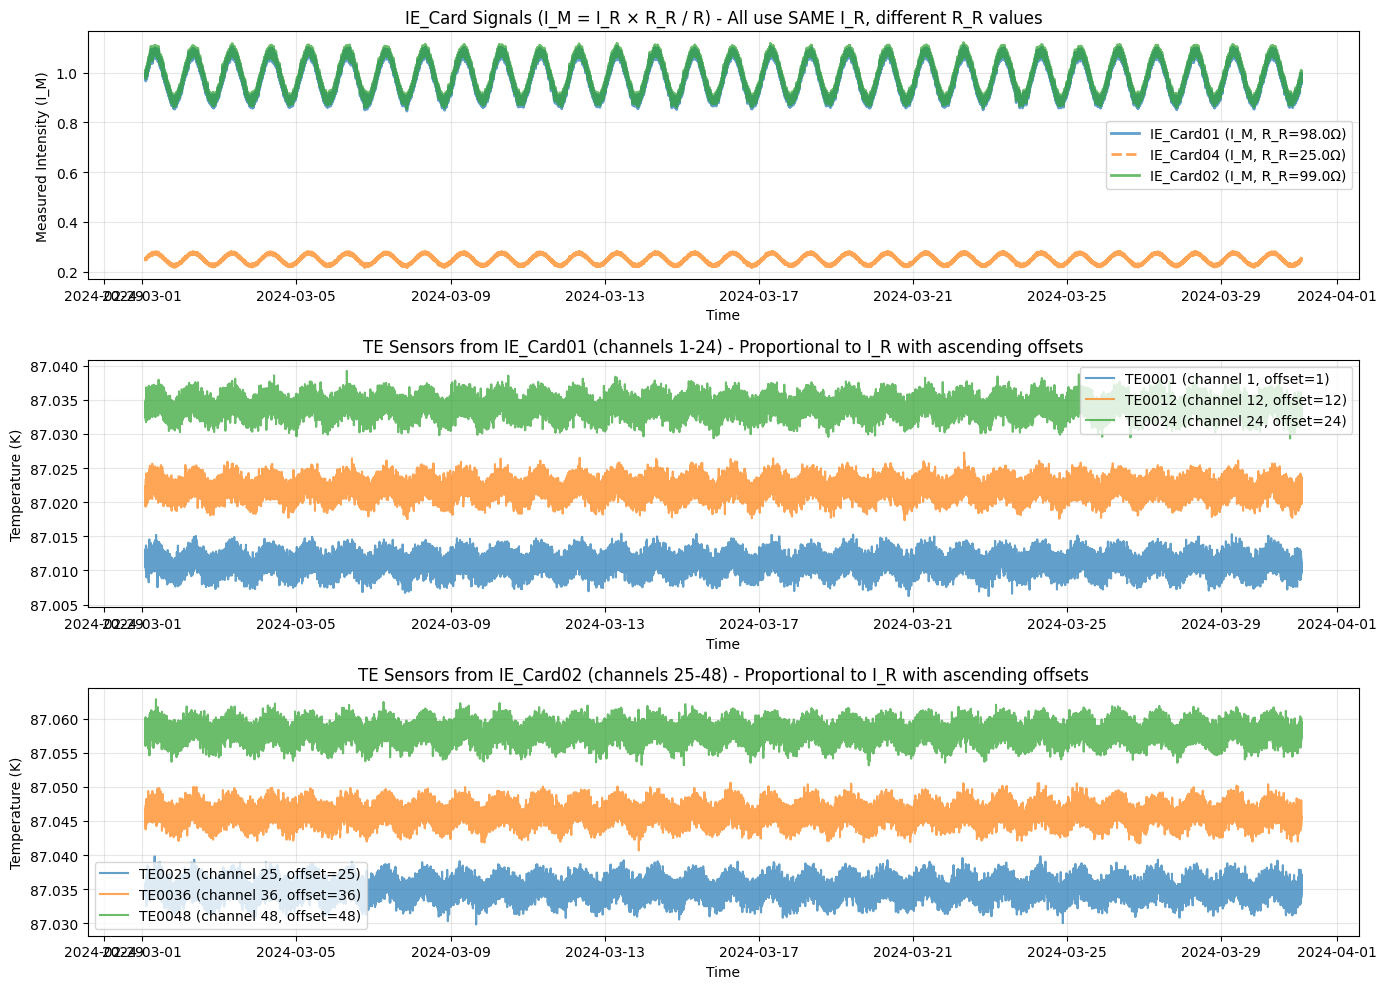

In [40]:
# Visualize the relationship between TE sensors and IE_Card signals
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot IE_Card signals (I_M = I_R * R_R / R)
# Show IE_Card01, IE_Card04 (with R_R=25), and one other for comparison
axes[0].plot(datetime_index, mock_data['IE_Card01'], label=f'IE_Card01 (I_M, R_R={R_R_dict["IE_Card01"]:.1f}Ω)', alpha=0.7, linewidth=2)
axes[0].plot(datetime_index, mock_data['IE_Card04'], label=f'IE_Card04 (I_M, R_R={R_R_dict["IE_Card04"]:.1f}Ω)', alpha=0.7, linewidth=2, linestyle='--')
axes[0].plot(datetime_index, mock_data['IE_Card02'], label=f'IE_Card02 (I_M, R_R={R_R_dict["IE_Card02"]:.1f}Ω)', alpha=0.7, linewidth=2)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Measured Intensity (I_M)')
axes[0].set_title('IE_Card Signals (I_M = I_R × R_R / R) - All use SAME I_R, different R_R values')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot TE sensors from IE_Card01 (channels 1-24)
# Show a few examples with different offsets
axes[1].plot(datetime_index, mock_data['TE0001'], label='TE0001 (channel 1, offset=1)', alpha=0.7)
axes[1].plot(datetime_index, mock_data['TE0012'], label='TE0012 (channel 12, offset=12)', alpha=0.7)
axes[1].plot(datetime_index, mock_data['TE0024'], label='TE0024 (channel 24, offset=24)', alpha=0.7)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Temperature (K)')
axes[1].set_title('TE Sensors from IE_Card01 (channels 1-24) - Proportional to I_R with ascending offsets')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot TE sensors from IE_Card02 (channels 25-48) to show the relationship
axes[2].plot(datetime_index, mock_data['TE0025'], label='TE0025 (channel 25, offset=25)', alpha=0.7)
axes[2].plot(datetime_index, mock_data['TE0036'], label='TE0036 (channel 36, offset=36)', alpha=0.7)
axes[2].plot(datetime_index, mock_data['TE0048'], label='TE0048 (channel 48, offset=48)', alpha=0.7)
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Temperature (K)')
axes[2].set_title('TE Sensors from IE_Card02 (channels 25-48) - Proportional to I_R with ascending offsets')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Save mock data to CSV if needed
# mock_data.to_csv('mock_data.csv', index=False)